# Zero-DCE++ with SE-Block — clean rebuild (v8: ablatable SE + trained denoiser)

## Why this exists
v7 fixed the architecture mismatch (depth-separable convs, single shared
3-channel curve — genuine Zero-DCE++, not original Zero-DCE). This version
(v8) adds the three research-gap directions agreed with the second author:

1. **Flexible SE-block placement** — `se_positions` lets the same model class
   place SE blocks after any of conv1–conv4, so an ablation table (SE@1 vs
   SE@2 vs SE@3 vs SE@4 vs none) is just a constructor argument, no
   duplicated model code.
2. **Configurable SE-block internal activation** — `se_activation` /
   `se_gate` let you swap ReLU→SiLU and Sigmoid→Hardsigmoid (as in
   MobileNetV3's SE variant) to test whether the narrow bottleneck
   (channels // reduction = 8 at reduction=4) was being starved.
3. **Trained noise-reduction head** — v7 only denoised at inference via a
   bilateral filter (pure post-processing, not part of the model). v8 adds
   a small trainable residual `DenoiseHead` plus a darkness-weighted
   `NoiseSuppressionLoss`, so noise suppression is now a real, trained
   architectural component — addressing Zero-DCE's well-documented
   noise-amplification weakness, not just papering over it after the fact.

**If you keep this version, note for BAB II/III:** the 24-channel description
in section 2.2.2 (and Rumus 2.1) still describes the ORIGINAL Zero-DCE's
per-iteration curves, not this architecture's single shared 3-channel curve —
that section needs updating regardless of which v8 sub-options you keep.
Additionally, if you keep the trained denoiser, your methodology section
should describe it and its loss term explicitly, since it changes the
model from purely zero-reference-for-enhancement to zero-reference-enhancement
+ a self-supervised (no paired noisy/clean data) denoising term.

### 1. Imports

In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060


### 2. SE-Block

Now configurable: `activation` controls the bottleneck's non-linearity
(`relu`, `prelu`, `silu`), `gate` controls the final channel-gate function
(`sigmoid`, `hardsigmoid`). Defaults (`relu`, `sigmoid`) exactly match the
v7 behavior, so nothing changes unless you deliberately pass a different
combination when constructing `DCENetLite`.

In [10]:
class SEBlock(nn.Module):
    _ACT = {
        'relu':  lambda: nn.ReLU(inplace=True),
        'prelu': lambda: nn.PReLU(),
        'silu':  lambda: nn.SiLU(inplace=True),   # aka Swish, used in EfficientNet's SE
        'gelu':  lambda: nn.GELU(),
    }
    _GATE = {
        'sigmoid':     lambda: nn.Sigmoid(),
        'hardsigmoid': lambda: nn.Hardsigmoid(inplace=True),  # used in MobileNetV3's SE
    }

    def __init__(self, channels, reduction=4, activation='relu', gate='sigmoid'):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            self._ACT[activation](),
            nn.Linear(channels // reduction, channels, bias=False),
            self._GATE[gate](),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

print('SE-Block defined (activation/gate configurable; defaults match v7: relu/sigmoid)')

SE-Block defined (activation/gate configurable; defaults match v7: relu/sigmoid)


### 3. Depth-Separable Convolution + DCE-Net++

`DepthSeparableConv2d` unchanged from v7. `DCENetLite` now takes
`se_positions` (a tuple of which of conv1–conv4 get an SE block — default
`(3,)` matches v7's fixed placement) plus `reduction`, `se_activation`,
`se_gate` which are forwarded straight to each `SEBlock`. For the SE
placement ablation, only this one constructor call needs to change between
runs — everything else (loss, dataset, training loop) stays identical.

In [11]:
class DepthSeparableConv2d(nn.Module):
    """Depthwise conv (per-channel spatial filter) + pointwise 1x1 (channel mixing).
    Matches TF's SeparableConv2D: depth_multiplier=1, RandomNormal(std=0.02) init."""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding,
                                    groups=in_channels, bias=True)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=True)
        nn.init.normal_(self.depthwise.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pointwise.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.depthwise.bias)
        nn.init.zeros_(self.pointwise.bias)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class DCENetLite(nn.Module):
    """Zero-DCE++ backbone: depth-separable convs, SE-Block(s) placeable at any
    of conv1-conv4, single shared 3-channel curve map (not per-iteration 24-channel)."""
    def __init__(self, filters=32, use_attention=True, se_positions=(3,),
                 reduction=4, se_activation='relu', se_gate='sigmoid', iterations=8):
        super().__init__()
        self.use_attention = use_attention
        self.se_positions  = set(se_positions) if use_attention else set()
        self.iterations    = iterations

        self.conv1 = DepthSeparableConv2d(3,          filters)
        self.conv2 = DepthSeparableConv2d(filters,    filters)
        self.conv3 = DepthSeparableConv2d(filters,    filters)
        self.conv4 = DepthSeparableConv2d(filters,    filters)
        self.conv5 = DepthSeparableConv2d(filters*2,  filters)  # concat(x3, x4)
        self.conv6 = DepthSeparableConv2d(filters*2,  filters)  # concat(x2, x5)
        self.conv7 = DepthSeparableConv2d(filters*2,  3)        # concat(x1, x6) -> 3ch only
        self.relu  = nn.ReLU(inplace=True)

        if use_attention:
            self.se_blocks = nn.ModuleDict({
                str(pos): SEBlock(filters, reduction=reduction,
                                   activation=se_activation, gate=se_gate)
                for pos in self.se_positions
            })

    def _se(self, feat, pos):
        if pos in self.se_positions:
            return self.se_blocks[str(pos)](feat)
        return feat

    def forward(self, x):
        x1 = self._se(self.relu(self.conv1(x)),  1)
        x2 = self._se(self.relu(self.conv2(x1)), 2)
        x3 = self._se(self.relu(self.conv3(x2)), 3)
        x4 = self._se(self.relu(self.conv4(x3)), 4)
        x5 = self.relu(self.conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.conv6(torch.cat([x2, x5], 1)))
        a_map = torch.tanh(self.conv7(torch.cat([x1, x6], 1)))  # [B, 3, H, W]
        return a_map


def enhance_image_with_curve(x, a_map, iterations=8):
    """Same curve applied `iterations` times, matching the reference repo exactly:
    enhanced = enhanced + a * (enhanced^2 - enhanced)"""
    enhanced = x
    for _ in range(iterations):
        enhanced = enhanced + a_map * (enhanced.pow(2) - enhanced)
    return torch.clamp(enhanced, 0, 1)


# se_positions=(3,), reduction=4, se_activation='relu', se_gate='sigmoid'
# reproduces v7 exactly. Change any of these for the ablation table.
model = DCENetLite(use_attention=True, se_positions=(3,),
                    reduction=4, se_activation='relu', se_gate='sigmoid').to(device)
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')

Model: 11,073 parameters


### 4. Loss Functions (ported from tested TF reference) + noise-suppression term

Same four-component zero-reference loss as v7 (`spa`, `exp`, `col`, `ill`),
plus a fifth optional term, `l_noise`, from `NoiseSuppressionLoss` (defined
in the next cell). `ZeroDCELoss.forward` now accepts `l_noise` and folds it
into the total with weight `w_noise` (default 50.0 — untuned starting
point, watch it in the progress bar the same way you already watch `exp`).
If you don't want the denoiser, just pass `l_noise=0.0` (the default) and
behavior is identical to v7.

In [12]:
class SpatialConsistencyLoss(nn.Module):
    def __init__(self):
        super().__init__()
        k_left  = torch.tensor([[0.,0.,0.],[-1.,1.,0.],[0.,0.,0.]]).view(1,1,3,3)
        k_right = torch.tensor([[0.,0.,0.],[0.,1.,-1.],[0.,0.,0.]]).view(1,1,3,3)
        k_up    = torch.tensor([[0.,-1.,0.],[0.,1.,0.],[0.,0.,0.]]).view(1,1,3,3)
        k_down  = torch.tensor([[0.,0.,0.],[0.,1.,0.],[0.,-1.,0.]]).view(1,1,3,3)
        self.register_buffer('k_left',  k_left)
        self.register_buffer('k_right', k_right)
        self.register_buffer('k_up',    k_up)
        self.register_buffer('k_down',  k_down)
        self.pool = nn.AvgPool2d(kernel_size=4, stride=4)

    def forward(self, inp, enh):
        inp_mean = inp.mean(dim=1, keepdim=True)
        enh_mean = enh.mean(dim=1, keepdim=True)
        inp_pool = self.pool(inp_mean)
        enh_pool = self.pool(enh_mean)

        d_inp = [F.conv2d(inp_pool, k, padding=1) for k in
                 (self.k_left, self.k_right, self.k_up, self.k_down)]
        d_enh = [F.conv2d(enh_pool, k, padding=1) for k in
                 (self.k_left, self.k_right, self.k_up, self.k_down)]

        return sum((di - de).pow(2) for di, de in zip(d_inp, d_enh)).mean()


class ExposureControlLoss(nn.Module):
    def __init__(self, e=0.6, patch_size=16):
        super().__init__()
        self.e = e
        self.pool = nn.AvgPool2d(kernel_size=patch_size, stride=patch_size)

    def forward(self, enhanced):
        mean_c = enhanced.mean(dim=1, keepdim=True)
        pooled = self.pool(mean_c)
        return (pooled - self.e).pow(2).mean()


class ColorConstancyLoss(nn.Module):
    def forward(self, enhanced):
        mean_rgb = enhanced.mean(dim=[2, 3], keepdim=True)  # [B, 3, 1, 1]
        mr, mg, mb = mean_rgb[:, 0:1], mean_rgb[:, 1:2], mean_rgb[:, 2:3]
        d_rg = (mr - mg).pow(2)
        d_rb = (mr - mb).pow(2)
        d_gb = (mb - mg).pow(2)
        return torch.sqrt(d_rg + d_rb + d_gb + 1e-8).mean()


class IlluminationSmoothnessLoss(nn.Module):
    def forward(self, alpha_map):
        b, c, h, w = alpha_map.shape
        count_h = (w - 1) * c
        count_w = w * (c - 1)

        tv_h = (alpha_map[:, :, 1:, :] - alpha_map[:, :, :h-1, :]).pow(2).sum() / count_h
        tv_w = (alpha_map[:, :, :, 1:] - alpha_map[:, :, :, :w-1]).pow(2).sum() / count_w

        return 2 * (tv_h + tv_w) / b


class NoiseSuppressionLoss(nn.Module):
    """Penalizes the INCREASE in local pixel variation from input to enhanced
    (not the enhanced image's raw variation), so it can't be minimized by
    flattening the whole image to black -- its minimum is reached when
    enhanced's local texture matches the input's. Dark-region weighting uses
    a threshold (dark_threshold) rather than (1 - mean), since for a
    low-light dataset nearly the whole frame is dark and (1-mean) ends up
    weighting almost everything near 1."""
    def __init__(self, dark_threshold=0.3):
        super().__init__()
        self.dark_threshold = dark_threshold

    def forward(self, enhanced, input_img):
        def grad(t):
            gh = (t[:, :, 1:, :] - t[:, :, :-1, :]).abs()
            gw = (t[:, :, :, 1:] - t[:, :, :, :-1]).abs()
            return gh, gw

        enh_gh, enh_gw = grad(enhanced)
        inp_gh, inp_gw = grad(input_img)

        excess_h = (enh_gh - inp_gh).clamp(min=0)   # only the EXTRA noise, never negative
        excess_w = (enh_gw - inp_gw).clamp(min=0)

        input_mean  = input_img.mean(dim=1, keepdim=True)
        dark_weight = torch.clamp((self.dark_threshold - input_mean) / self.dark_threshold, 0, 1)

        return (excess_h * dark_weight[:, :, 1:, :]).mean() + (excess_w * dark_weight[:, :, :, 1:]).mean()


class DenoiseHead(nn.Module):
    """Lightweight learned denoiser applied after curve enhancement.
    Depthwise-separable, residual, output scaled small (x0.1) so it corrects
    noise rather than repainting the image."""
    def __init__(self, channels=16):
        super().__init__()
        self.conv1 = DepthSeparableConv2d(3, channels)
        self.conv2 = DepthSeparableConv2d(channels, 3)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, enhanced):
        residual = self.relu(self.conv1(enhanced))
        residual = torch.tanh(self.conv2(residual)) * 0.1
        return torch.clamp(enhanced + residual, 0, 1)


class ZeroDCELoss(nn.Module):
    """Combines all four zero-reference terms (reference repo's LITE weights,
    as tuned in v7) plus an optional fifth noise-suppression term."""
    def __init__(self, e=0.52, patch_size=16,
                 w_spa=5.0, w_exp=20.0, w_col=5.0, w_ill=400.0, w_noise=5.0): # changed w_noise from 50.0 to 5.0 to reduce noise suppression weight, allowing for better detail preservation
        super().__init__()
        self.spa = SpatialConsistencyLoss()
        self.exp = ExposureControlLoss(e=e, patch_size=patch_size)
        self.col = ColorConstancyLoss()
        self.ill = IlluminationSmoothnessLoss()
        self.w_spa, self.w_exp, self.w_col, self.w_ill, self.w_noise = \
            w_spa, w_exp, w_col, w_ill, w_noise

    def forward(self, enhanced, input_img, a_map, l_noise=None):
        l_spa = self.spa(input_img, enhanced)
        l_exp = self.exp(enhanced)
        l_col = self.col(enhanced)
        l_ill = self.ill(a_map)
        if l_noise is None:
            l_noise = torch.zeros((), device=enhanced.device)
        total = (self.w_spa * l_spa + self.w_exp * l_exp
                 + self.w_col * l_col + self.w_ill * l_ill
                 + self.w_noise * l_noise)
        return total, l_spa, l_exp, l_col, l_ill, l_noise

loss_fn       = ZeroDCELoss().to(device)
noise_loss_fn = NoiseSuppressionLoss().to(device)
denoise_head  = DenoiseHead().to(device)
print('Loss functions defined (lite weights: spa=5, exp=20, col=5, ill=400, noise=50)')
print(f'DenoiseHead: {sum(p.numel() for p in denoise_head.parameters()):,} parameters')

Loss functions defined (lite weights: spa=5, exp=20, col=5, ill=400, noise=50)
DenoiseHead: 305 parameters


### 5. Dataset (LOL-v2 Real_captured, paired Low/Normal)

Unchanged from v4/v5 — `normal` is loaded for later PSNR/SSIM evaluation, not used in training (this architecture trains zero-reference, exactly like the original).

In [13]:
class LOLDataset(Dataset):
    def __init__(self, image_pairs, img_size=256, augment=False): # changed from 512 to 256, refferences from keras example
        self.image_pairs = image_pairs
        self.img_size    = img_size
        self.augment     = augment
        self.resize_size = int(img_size * 1.15)

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img    = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')

        # Resize by SHORT SIDE — preserves aspect ratio
        low_img    = TF.resize(low_img,    self.resize_size, interpolation=Image.BILINEAR)
        normal_img = TF.resize(normal_img, self.resize_size, interpolation=Image.BILINEAR)

        if self.augment:
            i, j, h, w = transforms.RandomCrop.get_params(
                low_img, (self.img_size, self.img_size))
            low_img    = TF.crop(low_img,    i, j, h, w)
            normal_img = TF.crop(normal_img, i, j, h, w)
            if torch.rand(1) > 0.5:
                low_img    = TF.hflip(low_img)
                normal_img = TF.hflip(normal_img)
        else:
            low_img    = TF.center_crop(low_img,    self.img_size)
            normal_img = TF.center_crop(normal_img, self.img_size)

        return {
            'low':      TF.to_tensor(low_img),
            'normal':   TF.to_tensor(normal_img),
            'filename': pair['filename']
        }

def load_image_pairs(data_path):
    low_p  = data_path / 'Low'
    norm_p = data_path / 'Normal'
    lows   = sorted([f for f in os.listdir(low_p)  if f.endswith(('.jpg','.png'))])
    norms  = sorted([f for f in os.listdir(norm_p) if f.endswith(('.jpg','.png'))])
    assert len(lows)==len(norms), f'Pair mismatch: {len(lows)} vs {len(norms)}'
    return [{'low':str(low_p/l),'normal':str(norm_p/n),'filename':l}
            for l,n in zip(lows,norms)]

BASE_PATH    = Path('LOL-v2')
train_pairs  = load_image_pairs(BASE_PATH / 'Real_captured' / 'Train')
test_pairs   = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')
print(f'LOL-v2: {len(train_pairs)} train, {len(test_pairs)} test')

BATCH_SIZE  = 8
IMG_SIZE    = 512
train_loader = DataLoader(LOLDataset(train_pairs, IMG_SIZE, augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(LOLDataset(test_pairs,  IMG_SIZE, augment=False),
                          batch_size=1,          shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

LOL-v2: 689 train, 100 test
Train batches: 87 | Test batches: 100


### 6. Training

Same structure as v7 (gradient accumulation, collapse guard, early
stopping). Two additions: `denoise_head`'s parameters are included in the
optimizer so it trains jointly with the main model, and `l_noise` is
tracked in `history` alongside the other four loss components. Checkpoint
now saves both `model` and `denoise_head` state dicts under one file.

In [14]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5 # originally 1e-4, changed to 1e-5 to reduce overfitting and improve generalization
NUM_EPOCHS    = 200
PATIENCE      = 35
ACCUM_STEPS   = 2
NOISE_WARMUP_EPOCHS = 20
CHECKPOINT    = 'best_zerodce_pp_seblock.pth'

optimizer = optim.Adam(list(model.parameters()) + list(denoise_head.parameters()),
                        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

history = {'loss':[],'spa':[],'exp':[],'col':[],'ill':[],'noise':[],'lr':[]}
best_loss     = float('inf')
no_improve    = 0
stopped_epoch = NUM_EPOCHS

print(f"{'='*60}")
print(f'TRAINING Zero-DCE++ (depth-separable) + SE-Block + DenoiseHead \u2014 max {NUM_EPOCHS} epochs, patience={PATIENCE}')
print(f'Effective batch: {BATCH_SIZE}\u00d7{ACCUM_STEPS} = {BATCH_SIZE*ACCUM_STEPS}')
print(f"{'='*60}")

for epoch in range(NUM_EPOCHS):
    model.train()
    denoise_head.train()
    totals = dict(loss=0, spa=0, exp=0, col=0, ill=0, noise=0)

    loss_fn.w_noise = 5.0 * min(1.0, epoch / NOISE_WARMUP_EPOCHS) # gradually increase noise suppression weight over first 20 epochs

    optimizer.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'[{epoch+1}/{NUM_EPOCHS}]')

    for step, batch in pbar:
        low_imgs = batch['low'].to(device)

        a_map    = model(low_imgs)
        enhanced = enhance_image_with_curve(low_imgs, a_map)
        enhanced = denoise_head(enhanced)
        l_noise  = noise_loss_fn(enhanced, low_imgs)

        loss, l_spa, l_exp, l_col, l_ill, l_noise = loss_fn(enhanced, low_imgs, a_map, l_noise)

        (loss / ACCUM_STEPS).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(denoise_head.parameters()), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        totals['loss']  += loss.item()
        totals['spa']   += l_spa.item()
        totals['exp']   += l_exp.item()
        totals['col']   += l_col.item()
        totals['ill']   += l_ill.item()
        totals['noise'] += l_noise.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'exp': f'{l_exp.item():.4f}',
                           'noise': f'{l_noise.item():.4f}'})

    n = len(train_loader)
    avg_loss = totals['loss'] / n
    for k in ['loss','spa','exp','col','ill','noise']:
        history[k].append(totals[k] / n)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Collapse guard: check mean brightness every 10 epochs
    if (epoch + 1) % 10 == 0:
        model.eval(); denoise_head.eval()
        with torch.no_grad():
            sample = next(iter(train_loader))['low'].to(device)
            a_s    = model(sample)
            e_s    = denoise_head(enhance_image_with_curve(sample, a_s))
            mean_brightness = e_s.mean().item()
        model.train(); denoise_head.train()
        print(f'  [Epoch {epoch+1}] mean_brightness={mean_brightness:.4f}', end='')
        if mean_brightness < 0.1:
            print(' \u2014 COLLAPSE DETECTED, stopping!')
            stopped_epoch = epoch + 1
            break
        else:
            print(f' | no_improve={no_improve}/{PATIENCE}')

    # Early stopping
    if avg_loss < best_loss:
        best_loss  = avg_loss
        no_improve = 0
        torch.save({'model': model.state_dict(),
                     'denoise_head': denoise_head.state_dict()}, CHECKPOINT)
        print(f'  Epoch {epoch+1}: loss={avg_loss:.6f}  [BEST saved]')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            stopped_epoch = epoch + 1
            print(f'  Early stopping at epoch {stopped_epoch}')
            break

    scheduler.step()

print(f"\n{'='*60}")
print(f'DONE \u2014 best loss: {best_loss:.6f} | stopped at epoch: {stopped_epoch}')
print(f"{'='*60}")

TRAINING Zero-DCE++ (depth-separable) + SE-Block + DenoiseHead — max 200 epochs, patience=35
Effective batch: 8×2 = 16


[1/200]: 100%|██████████| 87/87 [01:06<00:00,  1.31it/s, loss=4.3126, exp=0.2097, noise=0.0020]


  Epoch 1: loss=4.376984  [BEST saved]


[2/200]: 100%|██████████| 87/87 [00:43<00:00,  2.01it/s, loss=3.9604, exp=0.1964, noise=0.0011]


  Epoch 2: loss=4.296177  [BEST saved]


...

  [Epoch 160] mean_brightness=0.2696 | no_improve=20/35


[170/200]: 100%|██████████| 87/87 [00:43<00:00,  2.02it/s, loss=0.9551, exp=0.0244, noise=0.0170]


  [Epoch 170] mean_brightness=0.4128 | no_improve=30/35


[174/200]: 100%|██████████| 87/87 [00:42<00:00,  2.03it/s, loss=1.7078, exp=0.0246, noise=0.0575]

  Early stopping at epoch 174

DONE — best loss: 1.780901 | stopped at epoch: 174


### 7. Training Curves

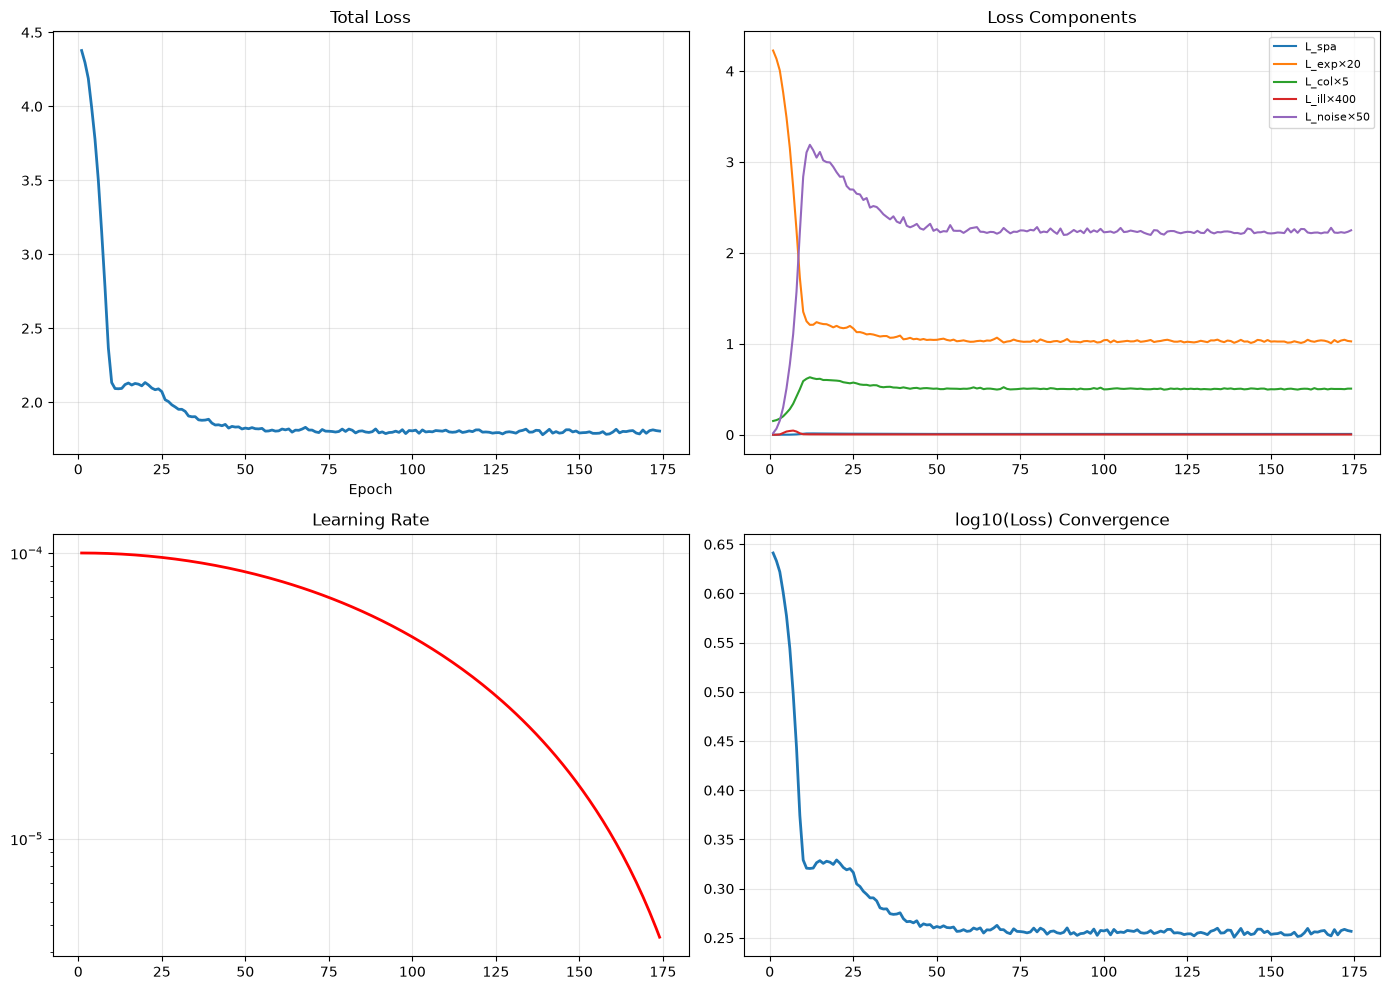

Saved: training_history_pp.png


In [15]:
ep = range(1, len(history['loss'])+1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(ep, history['loss'], linewidth=2)
axes[0,0].set_title('Total Loss'); axes[0,0].set_xlabel('Epoch')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ep, history['spa'],                    label='L_spa')
axes[0,1].plot(ep, np.array(history['exp'])*20,       label='L_exp\u00d720')
axes[0,1].plot(ep, np.array(history['col'])*5,        label='L_col\u00d75')
axes[0,1].plot(ep, np.array(history['ill'])*400,      label='L_ill\u00d7400')
axes[0,1].plot(ep, np.array(history['noise'])*50,     label='L_noise\u00d750')
axes[0,1].set_title('Loss Components')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(ep, history['lr'], color='red', linewidth=2)
axes[1,0].set_title('Learning Rate'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, np.log10(np.array(history['loss'])+1e-8), linewidth=2)
axes[1,1].set_title('log10(Loss) Convergence'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_pp.png', dpi=150)
plt.show()
print('Saved: training_history_pp.png')

### 8. Inference — trained denoiser + optional bilateral filter

The denoiser is now trained, not just applied at inference. `denoise=True`
still runs an additional bilateral filter pass on top for real-world photos
if you want extra smoothing; set it `False` to evaluate the model's own
learned denoising alone (e.g. for PSNR/SSIM against LOL-v2's Normal set).

In [16]:
def enhance_single_image(image_path, checkpoint=CHECKPOINT,
                          se_positions=(3,), reduction=4,
                          se_activation='relu', se_gate='sigmoid',
                          denoise=True, d=9, sigma_color=75, sigma_space=75):
    ckpt = torch.load(checkpoint, map_location=device)

    m = DCENetLite(use_attention=True, se_positions=se_positions, reduction=reduction,
                   se_activation=se_activation, se_gate=se_gate).to(device)
    m.load_state_dict(ckpt['model'])
    m.eval()

    dn = DenoiseHead().to(device)
    dn.load_state_dict(ckpt['denoise_head'])
    dn.eval()

    img = Image.open(image_path).convert('RGB')
    inp = TF.to_tensor(img).unsqueeze(0).to(device)

    with torch.no_grad():
        enh = dn(enhance_image_with_curve(inp, m(inp)))

    enh_np = (enh.squeeze(0).cpu().permute(1,2,0).numpy()*255).astype(np.uint8)

    if denoise:
        bgr    = cv2.cvtColor(enh_np, cv2.COLOR_RGB2BGR)
        bgr    = cv2.bilateralFilter(bgr, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        enh_np = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(np.array(img)); axes[0].set_title('Input (low-light)');  axes[0].axis('off')
    axes[1].imshow(enh_np);        axes[1].set_title('Enhanced (Zero-DCE++ + DenoiseHead)' + (' + Bilateral' if denoise else ''))
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('inference_pp.png', dpi=150)
    plt.show()
    return enh_np

print('Usage:')
print('  enhance_single_image(\"your_photo.jpg\", denoise=True)   # real-world photos, extra smoothing on top')
print('  enhance_single_image(\"lolv2_test.jpg\", denoise=False)  # metric evaluation, learned denoiser only')
print('  # match se_positions/reduction/se_activation/se_gate to whatever CHECKPOINT was trained with')

Usage:
  enhance_single_image("your_photo.jpg", denoise=True)   # real-world photos, extra smoothing on top
  enhance_single_image("lolv2_test.jpg", denoise=False)  # metric evaluation, learned denoiser only
  # match se_positions/reduction/se_activation/se_gate to whatever CHECKPOINT was trained with


---
### Version History

| Version | Key issue | Status |
|---|---|---|
| v1 (original) | `tanh*0.15`, wrong loss weights, broken pairing | Fixed in v2 |
| v2 | Working baseline | Good |
| v3 | `L_tv_enh` weight=500 \u2192 mode collapse to black | **Broken** |
| v4 | `L_tv_enh` removed, exposure upgraded to per-patch MSE, collapse guard added | Good (standard convs, 24-ch curve = original Zero-DCE architecture) |
| v5 | Added `DPEDColorLoss` + `VGGContentLoss` (LOL-v2 GT), single optimizer | Improved metrics, green-cast bias persisted |
| v6 | Added `ChannelBalanceLoss` \u2014 direct per-channel mean matching | Targeted fix for the cast |
| v7 | Hybrid losses removed entirely. Architecture rebuilt with depth-separable convs + single shared 3-channel curve, matching genuine Zero-DCE++. SE-Block fixed after Conv3. | Good (current baseline before v8) |
| **v8 (this notebook)** | SE-Block placement (`se_positions`) and internal activation (`se_activation`/`se_gate`) made configurable for ablation. Added a trained `DenoiseHead` + darkness-weighted `NoiseSuppressionLoss`, replacing inference-only bilateral filtering with a real trained noise-reduction component. | **Current** |

**Reminder:** BAB II \u00a72.2.2 and Rumus 2.1 still describe the 24-channel/per-iteration-curve
architecture from v1\u2013v6 (which was actually original Zero-DCE). Update that section to
describe the single shared 3-channel curve. If the trained DenoiseHead is kept, also add a
methodology paragraph describing it and `NoiseSuppressionLoss` explicitly, since it's now a
trained component, not post-processing.
